In [28]:
import os
import pandas as pd

# Descargar dataset NFL Combine (2000-2022)
os.makedirs("data", exist_ok=True)
os.system("kaggle datasets download mitchellweg1/nfl-combine-results-dataset-2000-2022 -p data --unzip")

print("Descarga completa.")

Descarga completa.


In [29]:
# Explorar archivos descargados
for f in os.listdir("data"):
    print(f)

2000_combine.csv
2001_combine.csv
2002_combine.csv
2003_combine.csv
2004_combine.csv
2005_combine.csv
2006_combine.csv
2007_combine.csv
2008_combine.csv
2009_combine.csv
2010_combine.csv
2011_combine.csv
2012_combine.csv
2013_combine.csv
2014_combine.csv
2015_combine.csv
2016_combine.csv
2017_combine.csv
2018_combine.csv
2019_combine.csv
2020_combine.csv
2021_combine.csv
2022_combine.csv
nfl_combined.csv


In [30]:
import glob

# Leer y combinar todos los CSV de la carpeta data
csv_files = sorted(glob.glob("data/*_combine.csv"))
print(f"Archivos encontrados: {len(csv_files)}")

df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Guardar como un solo CSV
df_all.to_csv("data/nfl_combined.csv", index=False)

print(f"Shape total: {df_all.shape}")
df_all.head()

Archivos encontrados: 23
Shape total: (7680, 11)


,Player,Pos,School,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
0,John Abraham,OLB,South Carolina,6-4,252.0,4.55,NaN,NaN,NaN,NaN,NaN
1,Shaun Alexander,RB,Alabama,6-0,218.0,4.58,NaN,NaN,NaN,NaN,NaN
2,Darnell Alford,OT,Boston Col.,6-4,334.0,5.56,25.0,23.0,94.0,8.48,4.98
3,Kyle Allamon,TE,Texas Tech,6-2,253.0,4.97,29.0,NaN,104.0,7.29,4.49
4,Rashard Anderson,CB,Jackson State,6-2,206.0,4.55,34.0,NaN,123.0,7.18,4.15


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings #good practice while coding
warnings.filterwarnings('ignore')

In [32]:
#Load the data and select the colums
#here is the same as doing df.all=df just following TA steps
df = pd.read_csv(r"C:\Users\azcon\Data-Mining-Midterm-Project\data\nfl_combined.csv")
identifier = ["Player", "School"] 
target = ["Pos"] # (Y)
features = ["Ht","Wt","40yd","Vertical","Bench","Broad Jump","3Cone","Shuttle"]
df = df[ identifier + target + features]
print(df.shape)  
df.head()

(7680, 11)


,Player,School,Pos,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
0,John Abraham,South Carolina,OLB,6-4,252.0,4.55,NaN,NaN,NaN,NaN,NaN
1,Shaun Alexander,Alabama,RB,6-0,218.0,4.58,NaN,NaN,NaN,NaN,NaN
2,Darnell Alford,Boston Col.,OT,6-4,334.0,5.56,25.0,23.0,94.0,8.48,4.98
3,Kyle Allamon,Texas Tech,TE,6-2,253.0,4.97,29.0,NaN,104.0,7.29,4.49
4,Rashard Anderson,Jackson State,CB,6-2,206.0,4.55,34.0,NaN,123.0,7.18,4.15


In [33]:
# Convert Ht from "6-4" string format to numeric inches
def ht_to_inches(ht):
    try:
        feet, inches = str(ht).split('-')
        return int(feet) * 12 + int(inches)
    except:
        return np.nan

df['Ht'] = df['Ht'].apply(ht_to_inches)
print("Ht converted to inches successfully")
df[['Ht']].head()

Ht converted to inches successfully


,Ht
0,76.0
1,72.0
2,76.0
3,74.0
4,74.0


In [34]:
# Group positions into broader categories to improve classification
position_groups = {
    "QB": "Skill",   "RB": "Skill",  "WR": "Skill", "TE": "Skill", "FB": "Skill",
    "OT": "Lineman", "OG": "Lineman","C":  "Lineman","OL": "Lineman",
    "DE": "D-Line",  "DT": "D-Line", "DL": "D-Line","NT": "D-Line","EDGE": "D-Line",
    "LB": "Linebacker","ILB": "Linebacker","OLB": "Linebacker",
    "CB": "Secondary","S":  "Secondary","DB": "Secondary","SS": "Secondary","FS": "Secondary",
    "K":  "Special", "P":  "Special", "LS": "Special"
}

df["Pos"] = df["Pos"].map(position_groups)
df = df.dropna(subset=["Pos"])

print("Position groups distribution:")
print(df["Pos"].value_counts())
print(f"\nTotal samples: {len(df)}")

Position groups distribution:
Pos
Skill         2701
Secondary     1385
Lineman       1252
D-Line        1202
Linebacker     863
Special        277
Name: count, dtype: int64

Total samples: 7680


In [35]:
print(df.info())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7680 entries, 0 to 7679
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      7680 non-null   object 
 1   School      7680 non-null   object 
 2   Pos         7680 non-null   object 
 3   Ht          7651 non-null   float64
 4   Wt          7656 non-null   float64
 5   40yd        7206 non-null   float64
 6   Vertical    5932 non-null   float64
 7   Bench       5096 non-null   float64
 8   Broad Jump  5859 non-null   float64
 9   3Cone       4792 non-null   float64
 10  Shuttle     4895 non-null   float64
dtypes: float64(8), object(3)
memory usage: 660.1+ KB
None




In [36]:
print(df.describe())

                Ht           Wt         40yd     Vertical        Bench  \
count  7651.000000  7656.000000  7206.000000  5932.000000  5096.000000   
mean     73.788132   242.748694     4.776363    32.894606    20.751766   
std       2.644357    45.254869     0.304835     4.215423     6.384214   
min      64.000000   144.000000     4.220000    17.500000     2.000000   
25%      72.000000   205.000000     4.540000    30.000000    16.000000   
50%      74.000000   232.000000     4.690000    33.000000    21.000000   
75%      76.000000   280.000000     4.977500    36.000000    25.000000   
max      82.000000   384.000000     6.050000    46.500000    49.000000   

        Broad Jump        3Cone      Shuttle  
count  5859.000000  4792.000000  4895.000000  
mean    114.596518     7.284451     4.399387  
std       9.349189     0.417650     0.267074  
min      74.000000     6.280000     3.730000  
25%     109.000000     6.970000     4.200000  
50%     116.000000     7.190000     4.360000  
75% 

In [37]:
print(df.isnull().sum())

Player           0
School           0
Pos              0
Ht              29
Wt              24
40yd           474
Vertical      1748
Bench         2584
Broad Jump    1821
3Cone         2888
Shuttle       2785
dtype: int64


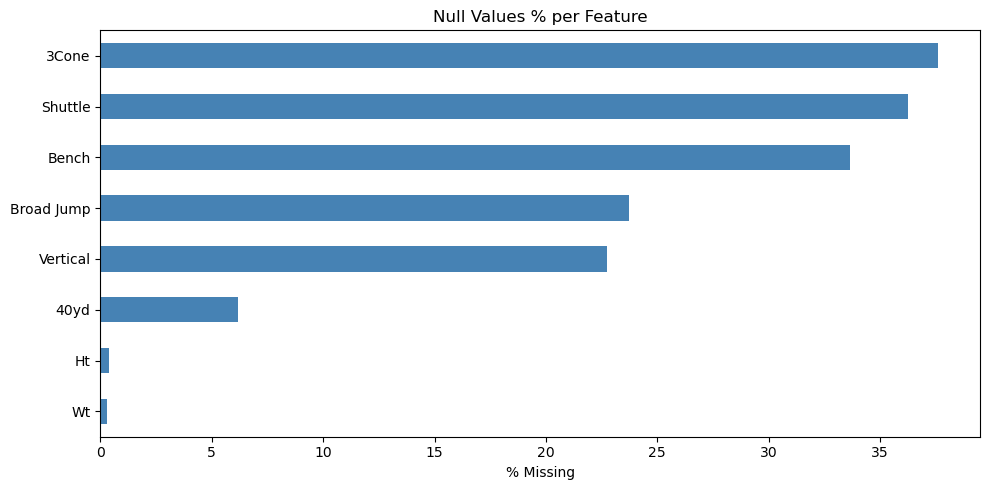

In [38]:
# Null values percentage bar chart
null_pct = df[features].isnull().mean() * 100
plt.figure(figsize=(10, 5))
null_pct.sort_values().plot(kind='barh', color='steelblue')
plt.title("Null Values % per Feature")
plt.xlabel("% Missing")
plt.tight_layout()
plt.show()

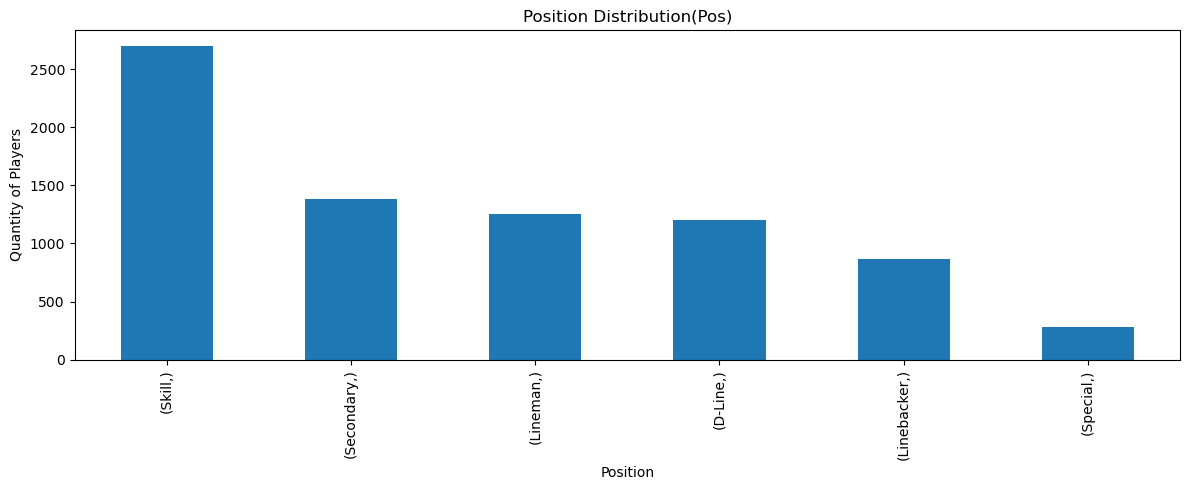

In [39]:
plt.figure(figsize=(12,5))
df[target].value_counts().plot(kind='bar')
plt.title("Position Distribution(Pos)")
plt.xlabel("Position")
plt.ylabel("Quantity of Players")
plt.tight_layout()
plt.show()

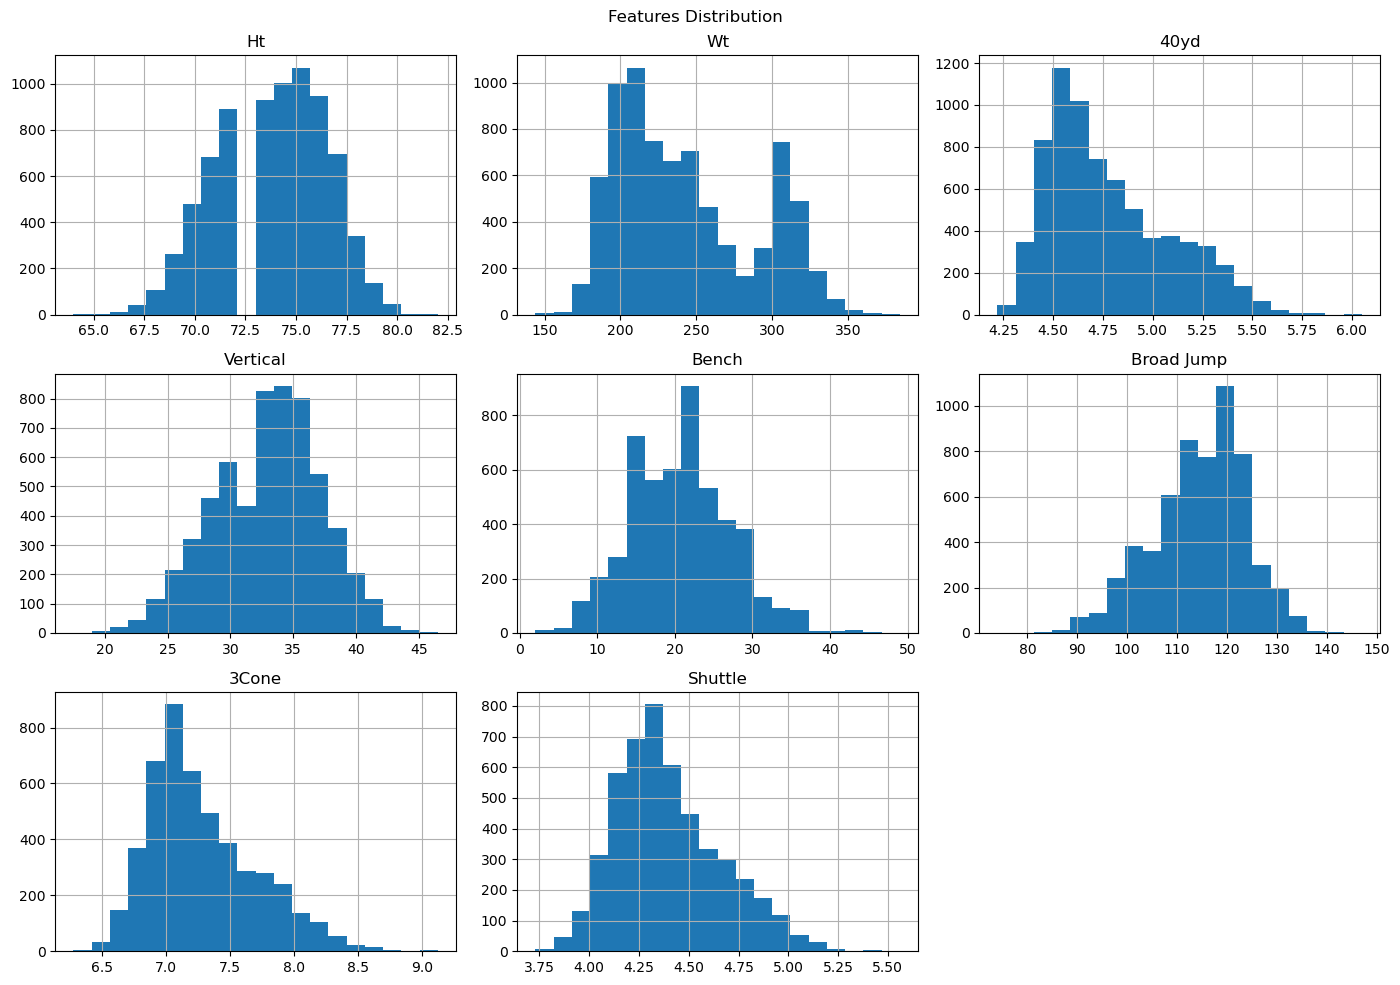

In [40]:

df[features].hist(bins= 20, figsize=(14,10))
plt.suptitle("Features Distribution")
plt.tight_layout()
plt.show()


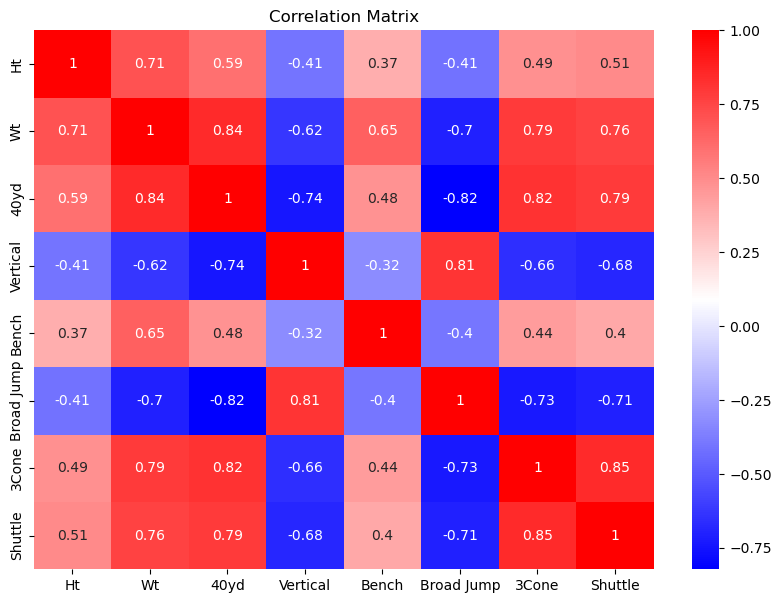

In [41]:
df_numeric = df[features].apply(pd.to_numeric,errors = 'coerce')


plt.figure(figsize=(10,7))
sns.heatmap(df_numeric.corr(),annot=True,cmap='bwr')
plt.title("Correlation Matrix")
plt.show()

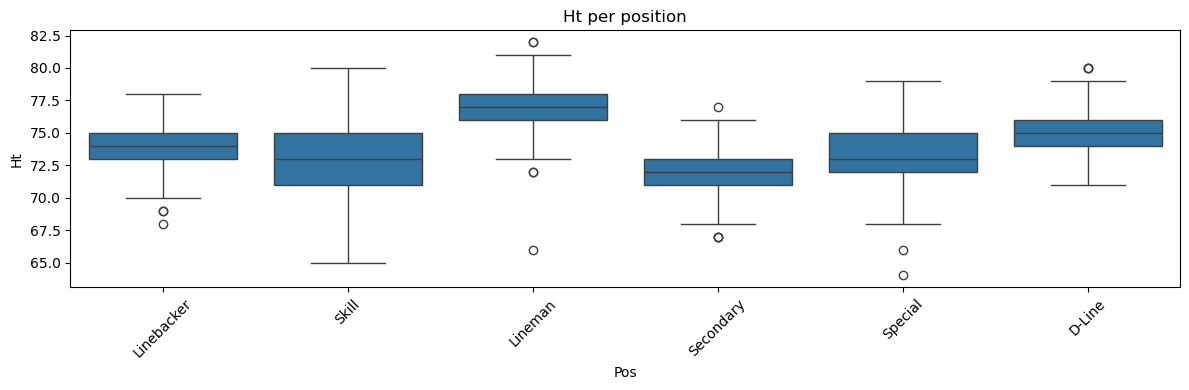

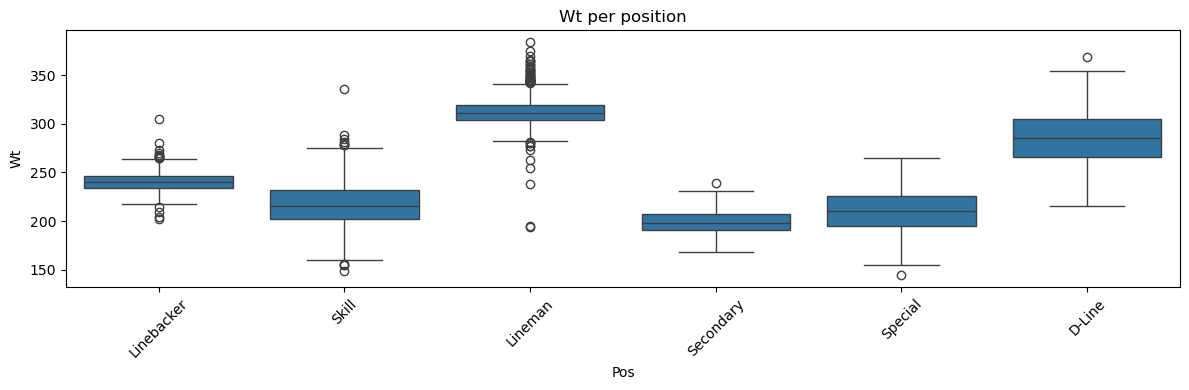

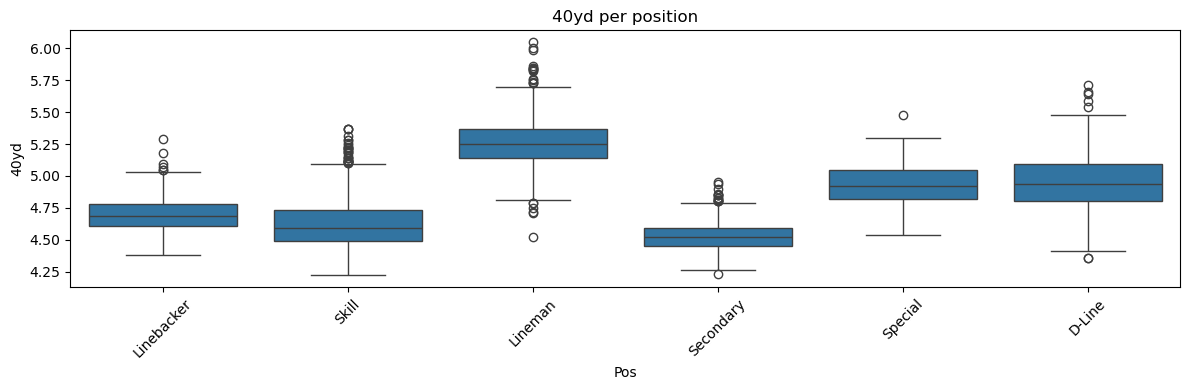

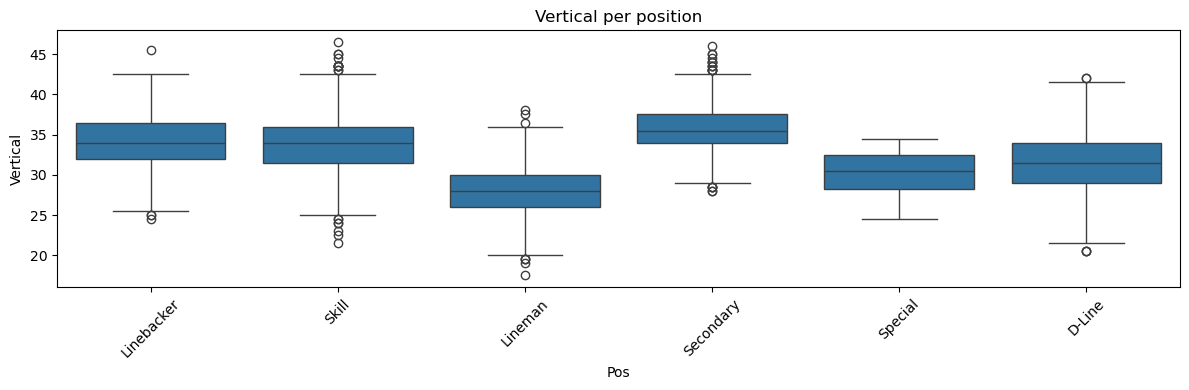

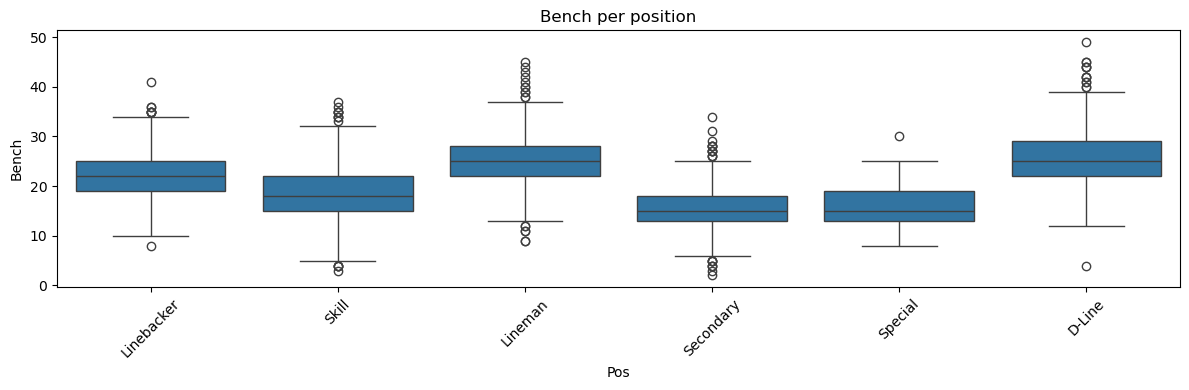

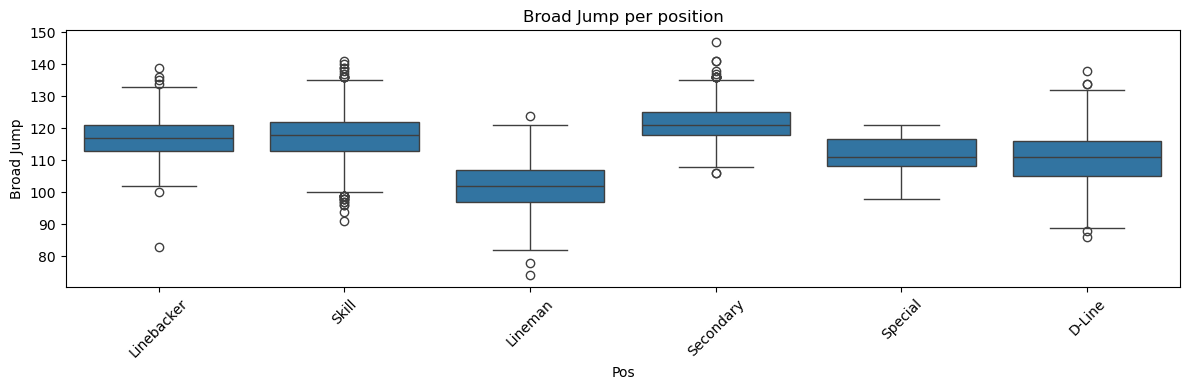

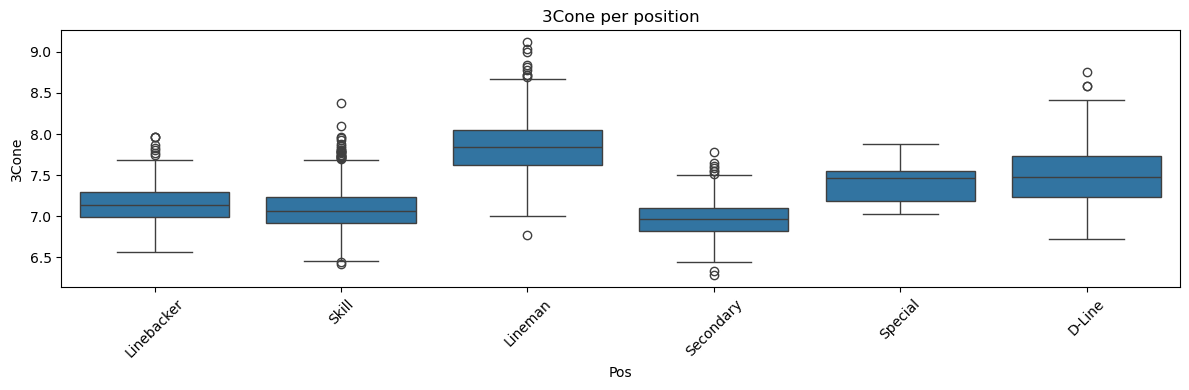

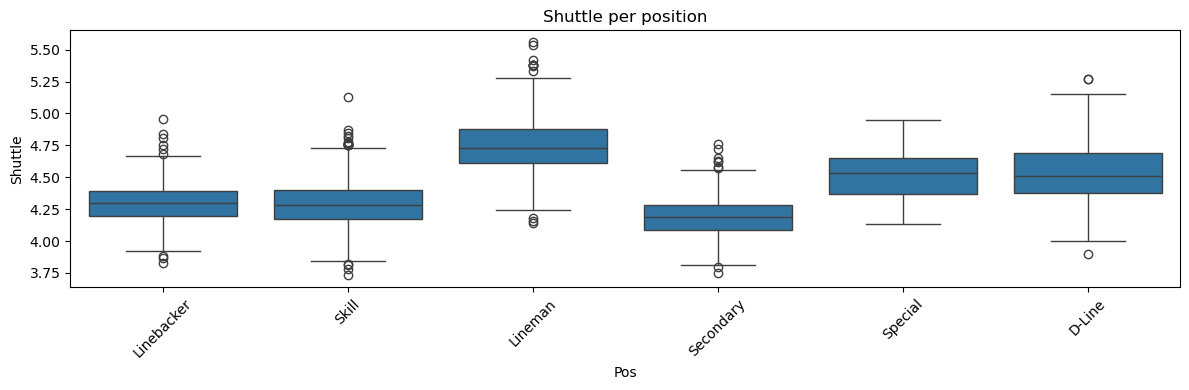

In [42]:
for col in features:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=target[0],y =col, data = df)
    plt.title(f"{col} per position")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

In [43]:
#Preprocessing

from sklearn.preprocessing  import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[features]= imputer.fit_transform(df[features])

le = LabelEncoder()
y = le.fit_transform(df[target[0]])

X= df[features].values
print(f"Classes: {le.classes_}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Classes: ['D-Line' 'Linebacker' 'Lineman' 'Secondary' 'Skill' 'Special']
X shape: (7680, 8), y shape: (7680,)


In [44]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |   Test:{X_test.shape}")

Train: (6144, 8)  |   Test:(1536, 8)


In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Test different hidden layer sizes
hidden_configs = [(32,), (64,), (128,), (64, 32), (128, 64)]
results_nodes = []

for config in hidden_configs:
    bpn = MLPClassifier(
        hidden_layer_sizes=config,
        activation='relu',
        learning_rate_init=0.01,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_nodes.append({"Hidden Layers": str(config), "Accuracy (%)": round(acc * 100, 2)})
    print(f"Config {config} → Accuracy: {acc:.4f}")

df_nodes = pd.DataFrame(results_nodes)
print("\n", df_nodes)

Config (32,) → Accuracy: 0.7103
Config (64,) → Accuracy: 0.6927
Config (128,) → Accuracy: 0.6908
Config (64, 32) → Accuracy: 0.6725
Config (128, 64) → Accuracy: 0.6608

   Hidden Layers  Accuracy (%)
0         (32,)         71.03
1         (64,)         69.27
2        (128,)         69.08
3      (64, 32)         67.25
4     (128, 64)         66.08


In [46]:
# Test different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
results_lr = []

for lr in learning_rates:
    bpn = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_lr.append({"Learning Rate": lr, "Accuracy (%)": round(acc * 100, 2)})
    print(f"LR {lr} → Accuracy: {acc:.4f}")

df_lr = pd.DataFrame(results_lr)
print("\n", df_lr)

LR 0.001 → Accuracy: 0.6862
LR 0.01 → Accuracy: 0.6725
LR 0.05 → Accuracy: 0.6654
LR 0.1 → Accuracy: 0.6543
LR 0.3 → Accuracy: 0.3607

    Learning Rate  Accuracy (%)
0          0.001         68.62
1          0.010         67.25
2          0.050         66.54
3          0.100         65.43
4          0.300         36.07


In [47]:
from sklearn.metrics import classification_report

# Best model with best config found above
best_bpn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)
best_bpn.fit(X_train, y_train)
y_pred = best_bpn.predict(X_test)

print(" Classification Report ")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Recalling: predict position for a new sample
sample = X_test[0].reshape(1, -1)
prediction = le.inverse_transform(best_bpn.predict(sample))
print(f"Recalling example → Predicted position: {prediction[0]}")
print(f"Actual position:    {le.inverse_transform([y_test[0]])[0]}")

 Classification Report 
              precision    recall  f1-score   support

      D-Line       0.67      0.64      0.66       243
  Linebacker       0.57      0.76      0.65       166
     Lineman       0.85      0.81      0.83       250
   Secondary       0.60      0.73      0.66       266
       Skill       0.69      0.58      0.63       554
     Special       0.62      0.58      0.60        57

    accuracy                           0.67      1536
   macro avg       0.67      0.68      0.67      1536
weighted avg       0.68      0.67      0.67      1536

Recalling example → Predicted position: Linebacker
Actual position:    Skill


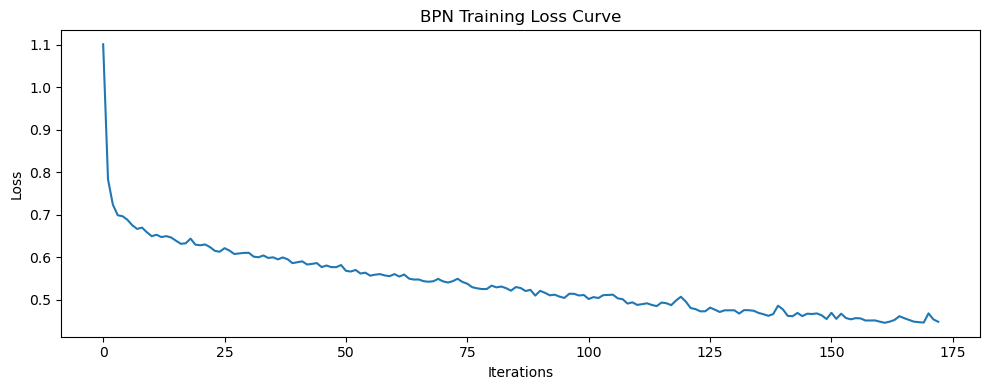

In [48]:
# Training loss curve (convergence)
plt.figure(figsize=(10, 4))
plt.plot(best_bpn.loss_curve_)
plt.title("BPN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()